In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Parameter

In [2]:
mu_m = 0.9       # 1/h
K_S = 0.21       # g/L
K_I = 1.5        # g/L
Y_XS = 0.6       # g/g
K_CL = 0.2       # mg/L
Y_OS = 160.0     # mg/g
M = 0.0314
V_L = 90.0       # L
eps = 0.2
V_G = eps * V_L  # L
G = 5000.0       # L/h
C_Li_in = 6.0    # mg/L
C_Gi_in = 250.0  # mg/L

Equations

In [3]:
y0_default = [1.0, 0.0, 6.0, 250.0] # [X, S, C_L, C_G]

def get_mu(S, C_L):
    S = max(0.0, S)
    C_L = max(0.0, C_L)
    
    # Haldane equation
    mu_S = S / (K_S + S + (S**2)/K_I)
    mu_O2 = C_L / (K_CL + C_L)
    return mu_m * mu_S * mu_O2

def fermenter_odes(t, y, F, KLa, Si):
    X, S, C_L, C_G = y
    
    mu = get_mu(S, C_L)
    C_L_star = M * C_G
    
    # Mass balances
    dX_dt = -(F/V_L)*X + mu*X
    dS_dt = (F/V_L)*(Si - S) - (1/Y_XS)*mu*X
    dCL_dt = (F/V_L)*(C_Li_in - C_L) - (Y_OS/Y_XS)*mu*X + KLa*(C_L_star - C_L)
    dCG_dt = (G/V_G)*(C_Gi_in - C_G) - KLa*(V_L/V_G)*(C_L_star - C_L)
    
    return [dX_dt, dS_dt, dCL_dt, dCG_dt]

def calc_OUR(mu_array, X_array):
    return (Y_OS / Y_XS) * mu_array * X_array * V_L

Part A : 

--- KLa ---
F (L/h)        Required KLa (1/h)  Min C_L (mg/L) 
6.50           155.58              0.6000         
7.38           15.82               0.6000         
8.25           15.48               0.6000         
9.12           15.25               0.6000         
10.00          15.08               0.6000         


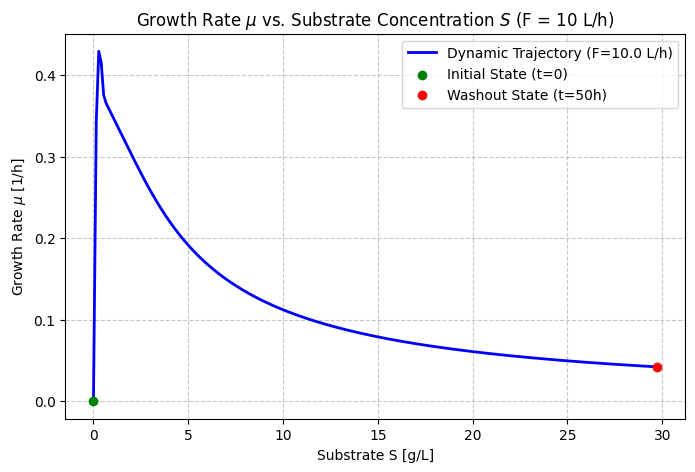

In [4]:
Si_default = 30.0 # g/L

def find_minimum_kla(F, cl_threshold=0.5, t_max=50):
    kla_low = 1.0
    kla_high = 300.0
    for _ in range(25):
        kla_mid = (kla_low + kla_high) / 2
        sol = solve_ivp(fermenter_odes, [0, t_max], y0_default, method='BDF', 
                        args=(F, kla_mid, Si_default), rtol=1e-6, atol=1e-6)
        
        if np.min(sol.y[2]) >= cl_threshold:
            kla_high = kla_mid
        else:
            kla_low = kla_mid
    return kla_high

feed_rates = np.linspace(6.5, 10.0, 5)
print("--- KLa ---")
print(f"{'F (L/h)':<15}{'Required KLa (1/h)':<20}{'Min C_L (mg/L)':<15}")
for F in feed_rates:
    req_kla = find_minimum_kla(F, cl_threshold=0.6)
    sol_v = solve_ivp(fermenter_odes, [0, 50], y0_default, method='BDF', 
                      args=(F, req_kla, Si_default), rtol=1e-6, atol=1e-6)
    print(f"{F:<15.2f}{req_kla:<20.2f}{np.min(sol_v.y[2]):<15.4f}")

F_plot = 10.0
KLa_plot = find_minimum_kla(F_plot, cl_threshold=0.5)

sol_plot = solve_ivp(fermenter_odes, [0, 50], y0_default, method='BDF', 
                      args=(F_plot, KLa_plot, Si_default), rtol=1e-6, atol=1e-6)

t_steps = np.linspace(0, 50, 1000)
X_vals = np.interp(t_steps, sol_plot.t, sol_plot.y[0])
S_vals = np.interp(t_steps, sol_plot.t, sol_plot.y[1])
CL_vals = np.interp(t_steps, sol_plot.t, sol_plot.y[2])

mu_vals = np.array([get_mu(S_vals[i], CL_vals[i]) for i in range(len(t_steps))])

plt.figure(figsize=(8, 5))
plt.plot(S_vals, mu_vals, color='blue', linewidth=2.0, label=f'Dynamic Trajectory (F={F_plot} L/h)')
plt.scatter(S_vals[0], mu_vals[0], color='green', zorder=5, label='Initial State (t=0)')
plt.scatter(S_vals[-1], mu_vals[-1], color='red', zorder=5, label='Washout State (t=50h)')

plt.title('Growth Rate $\\mu$ vs. Substrate Concentration $S$ (F = 10 L/h)')
plt.xlabel('Substrate S [g/L]')
plt.ylabel('Growth Rate $\\mu$ [1/h]')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Part B : 

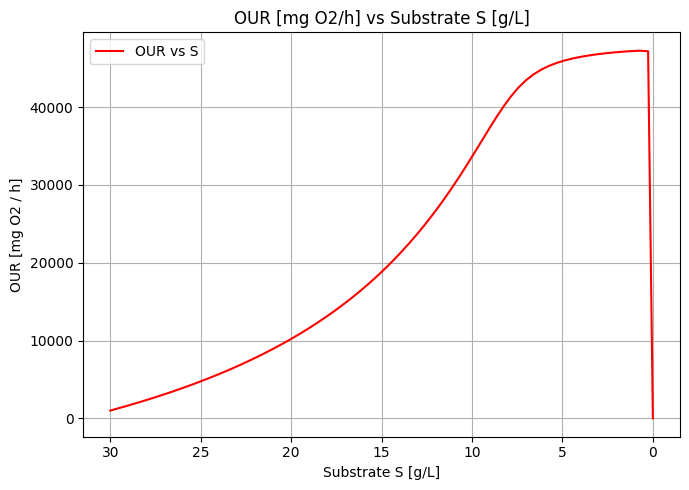

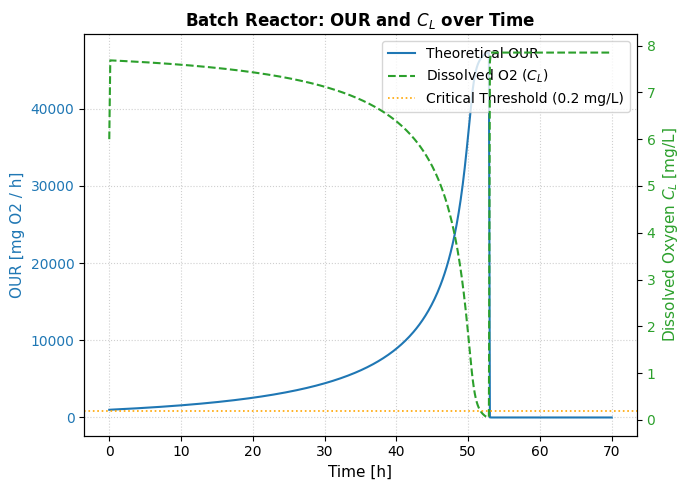

In [5]:
F_bc = 0.0
KLa_bc = 70.0
Si_bc = 30.0
y0_batch = [1.0, 30.0, 6.0, 250.0]

sol_bc = solve_ivp(fermenter_odes, [0, 70], y0_batch, method='BDF', 
                   args=(F_bc, KLa_bc, Si_bc), rtol=1e-6, atol=1e-6, dense_output=True)

t_bc = np.linspace(0, 70, 500)
y_bc = sol_bc.sol(t_bc)
X_bc, S_bc, CL_bc, CG_bc = y_bc

mu_bc = np.array([get_mu(S_bc[i], CL_bc[i]) for i in range(len(t_bc))])
OUR_bc = calc_OUR(mu_bc, X_bc)

plt.figure(figsize=(7, 5))
plt.plot(S_bc, OUR_bc, label='OUR vs S', linewidth=1.5, color='red')
plt.title('OUR [mg O2/h] vs Substrate S [g/L]')
plt.xlabel('Substrate S [g/L]')
plt.ylabel('OUR [mg O2 / h]')
plt.gca().invert_xaxis()  
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(7, 5))

color = 'tab:blue'
ax1.set_xlabel('Time [h]', fontsize=11)
ax1.set_ylabel('OUR [mg O2 / h]', color=color, fontsize=11)
ax1.plot(t_bc, OUR_bc, color=color, label='Theoretical OUR', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()  
color = 'tab:green'
ax2.set_ylabel('Dissolved Oxygen $C_L$ [mg/L]', color=color, fontsize=11)
ax2.plot(t_bc, CL_bc, color=color, linestyle='--', label='Dissolved O2 ($C_L$)', linewidth=1.5)
ax2.tick_params(axis='y', labelcolor=color)

ax2.axhline(y=0.2, color='orange', linestyle=':', label='Critical Threshold (0.2 mg/L)', linewidth=1.2)

plt.title('Batch Reactor: OUR and $C_L$ over Time', fontsize=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

fig.tight_layout()
plt.show()

Part C :

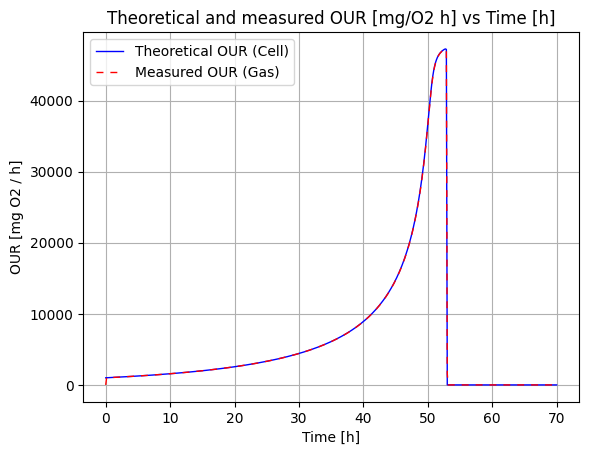

In [6]:
OUR_meas = G * (C_Gi_in - CG_bc)

plt.plot(t_bc, OUR_bc, label='Theoretical OUR (Cell)',linewidth=1.0, color='blue')
plt.plot(t_bc, OUR_meas, linestyle=(0, (5, 5)), label='Measured OUR (Gas)',linewidth=1.0, color='red')
plt.title('Theoretical and measured OUR [mg/O2 h] vs Time [h]')
plt.xlabel('Time [h]')
plt.ylabel('OUR [mg O2 / h]')
plt.grid(True)
plt.legend()

Part D :

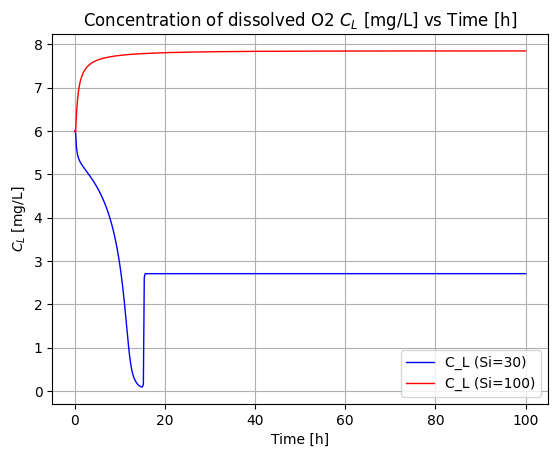

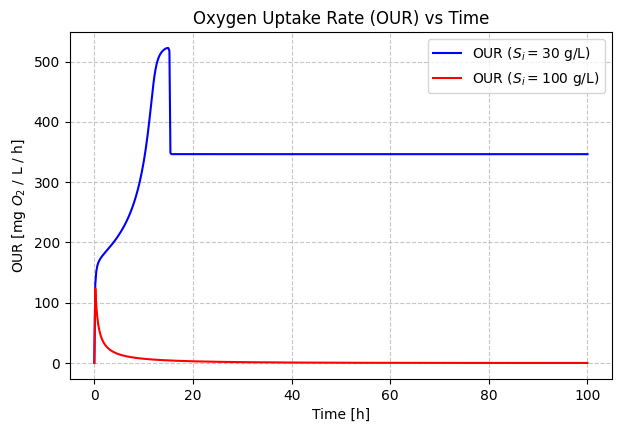

In [7]:
F_d = 6.5
KLa_d = 70.0

sol_d_30 = solve_ivp(fermenter_odes, [0, 100], y0_default, method='BDF', 
                     args=(F_d, KLa_d, 30.0), rtol=1e-6, atol=1e-6, dense_output=True)
sol_d_100 = solve_ivp(fermenter_odes, [0, 100], y0_default, method='BDF', 
                      args=(F_d, KLa_d, 100.0), rtol=1e-6, atol=1e-6, dense_output=True)

t_d = np.linspace(0, 100, 500)
y_d_30 = sol_d_30.sol(t_d)
y_d_100 = sol_d_100.sol(t_d)

our_30 = []
our_100 = []

for i in range(len(t_d)):
    # Pour Si = 30 g/L
    X_30, S_30, CL_30 = y_d_30[0, i], y_d_30[1, i], y_d_30[2, i]
    mu_30 = get_mu(S_30, CL_30)
    # Volumetric OUR = (Y_OS / Y_XS) * mu * X
    our_30.append((Y_OS / Y_XS) * mu_30 * X_30)
    
    # Pour Si = 100 g/L
    X_100, S_100, CL_100 = y_d_100[0, i], y_d_100[1, i], y_d_100[2, i]
    mu_100 = get_mu(S_100, CL_100)
    our_100.append((Y_OS / Y_XS) * mu_100 * X_100)

our_30 = np.array(our_30)
our_100 = np.array(our_100)

plt.plot(t_d, y_d_30[2, :], label='C_L (Si=30)', linewidth=1.0,color='blue')
plt.plot(t_d, y_d_100[2, :], label='C_L (Si=100)', linewidth=1.0, color='red')
plt.title('Concentration of dissolved O2 $C_L$ [mg/L] vs Time [h]')
plt.xlabel('Time [h]')
plt.ylabel('$C_L$ [mg/L]')
plt.grid(True)
plt.legend()
plt.show

plt.figure(figsize=(7, 4.5))
plt.plot(t_d, our_30, label='OUR ($S_i = 30$ g/L)', linewidth=1.5, color='blue')
plt.plot(t_d, our_100, label='OUR ($S_i = 100$ g/L)', linewidth=1.5, color='red')
plt.title('Oxygen Uptake Rate (OUR) vs Time')
plt.xlabel('Time [h]')
plt.ylabel('OUR [mg $O_2$ / L / h]')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.savefig('2.d_OUR.png', dpi=300, bbox_inches='tight')
plt.show()